In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv('ai_financial_market_daily_realistic_synthetic.csv')

In [3]:
data.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 10959 non-null  object 
 1   Company              10959 non-null  object 
 2   R&D_Spending_USD_Mn  10959 non-null  float64
 3   AI_Revenue_USD_Mn    10959 non-null  float64
 4   AI_Revenue_Growth_%  10959 non-null  float64
 5   Event                233 non-null    object 
 6   Stock_Impact_%       10959 non-null  float64
dtypes: float64(4), object(3)
memory usage: 599.4+ KB


In [5]:
data['Date'] = pd.to_datetime(data['Date'])

In [6]:
data.isna().sum()

Date                       0
Company                    0
R&D_Spending_USD_Mn        0
AI_Revenue_USD_Mn          0
AI_Revenue_Growth_%        0
Event                  10726
Stock_Impact_%             0
dtype: int64

In [7]:
data['Event'].value_counts()

Event
AI speech recognition release      37
AI Ads Optimization upgrade        32
AI partnership deal                32
AI-powered search update           32
AI Video Recommendation upgrade    29
AI ethics policy update            27
Cloud AI launch                    27
GPT-1 release                       1
GPT-2 release                       1
GPT-3 release                       1
Codex release                       1
DALL·E 2 release                    1
ChatGPT (GPT-3.5) launch            1
GPT-4 release                       1
GPT-5 release (predicted)           1
TensorFlow open-source release      1
AlphaGo beats Lee Sedol             1
BERT for Search launch              1
MUM Search Model launch             1
Bard chatbot launch                 1
Gemini AI release                   1
LLaMA 1 release                     1
LLaMA 2 release                     1
LLaMA 3 release (predicted)         1
Name: count, dtype: int64

Event feature gives the important updates in each company's AI market but having too many null values going to impact the study.Therefore, it is better to drop the columns

In [8]:
data.drop('Event',axis=1,inplace=True)

In [9]:
data.sample(7)

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Stock_Impact_%
7032,2024-04-02,Google,160.15,153.97,413.23,0.12
553,2016-07-07,OpenAI,6.73,1.49,49.17,0.71
577,2016-07-31,OpenAI,5.43,0.75,-25.50,-0.82
1142,2018-02-16,OpenAI,8.04,2.18,117.69,0.34
5808,2020-11-25,Google,118.91,73.56,145.19,-0.65
8587,2018-07-05,Meta,63.99,34.25,71.23,0.85
6646,2023-03-13,Google,147.98,129.13,330.43,0.10


In [10]:
print('The different AI developing companies: ',data['Company'].unique())
print(data.shape)

The different AI developing companies:  ['OpenAI' 'Google' 'Meta']
(10959, 6)


In [11]:
#Let us change column names for better readability
data.columns = ['Date','Company','Spendings','Revenue','Revenue_Growth','Stock_Impact']

#### AI Financial Market Analysis

In [12]:
#Total amount spent and revenue earned by each company on AI development in USD millions
print('The spendings are: ')
print(data.groupby('Company')['Spendings'].sum().reset_index())
print('The amount of revenue earned are: ')
print(data.groupby('Company')['Revenue'].sum().reset_index())

The spendings are: 
  Company  Spendings
0  Google  423341.14
1    Meta  264533.07
2  OpenAI   26482.77
The amount of revenue earned are: 
  Company    Revenue
0  Google  284498.38
1    Meta  189621.82
2  OpenAI    9462.89


In [18]:
Company_Spendings = data.groupby('Company')['Spendings'].sum()
Company_Revenue = data.groupby('Company')['Revenue'].sum()
Rich_data = pd.DataFrame({'Company':['Google','Meta','OpenAI'],'Spendings':Company_Spendings.values,'Revenue':Company_Revenue.values})
Rich_data['Profits'] = Rich_data['Revenue'] - Rich_data['Spendings']
Rich_data['Profit_per'] = (Rich_data['Spendings']/Rich_data['Revenue'])*100
Rich_data

,Company,Spendings,Revenue,Profits,Profit_per
0,Google,423341.14,284498.38,-138842.76,148.802654
1,Meta,264533.07,189621.82,-74911.25,139.505606
2,OpenAI,26482.77,9462.89,-17019.88,279.859218


##### Spendings vs Revenue
It is clear that all the companies from the dataset that are investing AI are not even meeting their breakdown point.Their revenue is only about 75% of their investments in AI.This tells us that a- Their investments and projects are not ending up successful b- the customer AI adoption rate is not up to their spendings and expectation

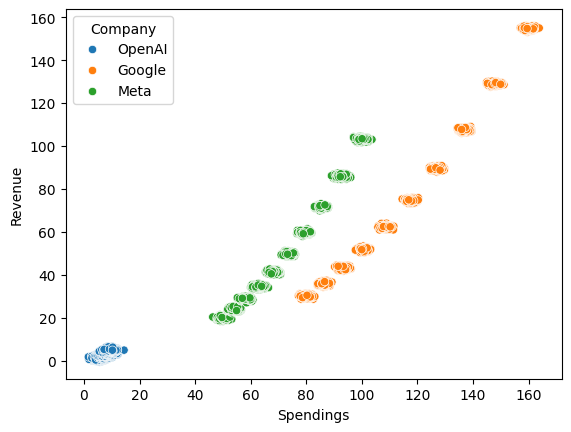

In [13]:
sns.scatterplot(x='Spendings',y='Revenue',hue='Company',data=data)
plt.show()

In [14]:
numeric_data = data.select_dtypes(include='number')
numeric_data.corr()

,Spendings,Revenue,Revenue_Growth,Stock_Impact
Spendings,1.000000,0.935030,0.291245,-0.004628
Revenue,0.935030,1.000000,0.530128,-0.000017
Revenue_Growth,0.291245,0.530128,1.000000,0.020937
Stock_Impact,-0.004628,-0.000017,0.020937,1.000000


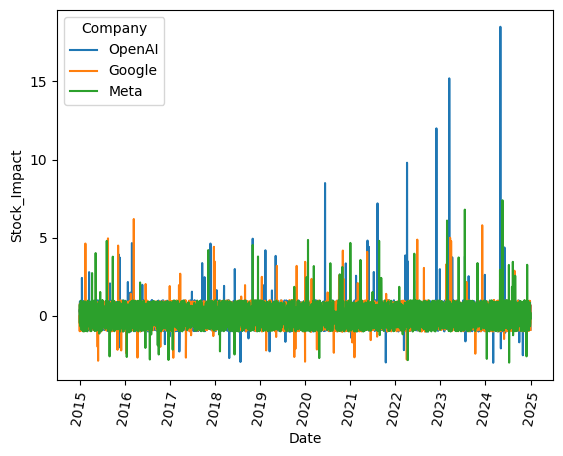

In [15]:
#Daily impact on stock market during the AI development programs for each company
sns.lineplot(x='Date',y='Stock_Impact',hue='Company',data=data)
plt.xticks(rotation=80)
plt.show()


#### Better performing Company in AI investments
Analyzing above plots, although all companies are not getting their expected revenue let alone any kind profits.Open AI is doing relatively better compared to the other 2 AI giants, their stock performance getting better over the time and they have less losses compared to the other two. Google and Meta have other business, products and projects that help them have enough money to rigirously invest in AI even when losses are incurred

In [16]:
data['Year'] = data['Date'].dt.year

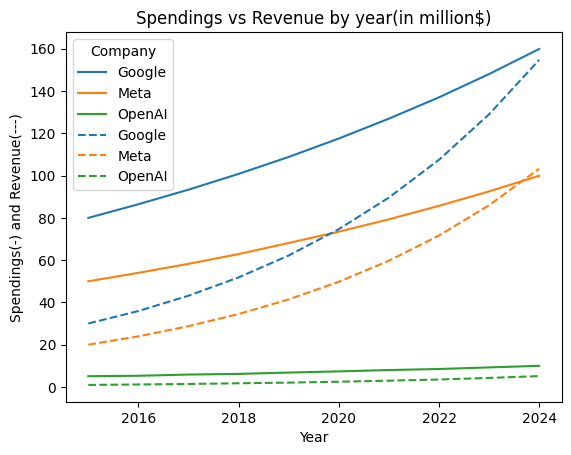

In [19]:
#Expenditure vs Revenue by year
yearly_data = data.groupby(['Year','Company'])[['Spendings','Revenue']].mean().reset_index()
sns.lineplot(x='Year',y='Spendings',hue='Company',data=yearly_data)
sns.lineplot(x='Year',y='Revenue',hue='Company',data=yearly_data,linestyle='--')
plt.xlabel('Year')
plt.ylabel('Spendings(-) and Revenue(---)')
plt.title('Spendings vs Revenue by year(in million$)')
plt.show()

#### Difference between (1)data['Date'].max() and (2)data['Date'].max().date()
(1) -- gives you the time stamp also along with date
(2) -- returns just the respective date
It comes down to the requirements.Below we need no.of days it took for the study, so we need (2) i.e., without timestamp to subtract end_date - start_date 

In [22]:
start_date = data['Date'].min().date()
end_date = data['Date'].max().date()
Days = (end_date - start_date).days
print('This is the first date of study: ',start_date)
print('This is the last date of study: ',end_date)
print('No.of days for the study: ', Days)

This is the first date of study:  2015-01-01
This is the last date of study:  2024-12-31
No.of days for the study:  3652


#### Event Impact analysis
I dropped the column 'Event' considering the no.of null values it had.But the stock market had seen impact due to those events

In [23]:
df = pd.read_csv('ai_financial_market_daily_realistic_synthetic.csv')
df.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09


In [24]:
df['Date'] = pd.to_datetime(df['Date'])

In [25]:
df.columns = ['Date','Company','Spendings','Revenue','Revenue_growth','Event','Stock_Impact']

In [26]:
event_data = df[df['Event'].notna()]

In [27]:
print('Total days: ',(df['Date'].max().date()-df['Date'].min().date()).days)
print('Total days that had an event: ',event_data.shape[0])

Total days:  3652
Total days that had an event:  233


In [28]:
#We use event_data(DataFrame separated for Event Impact analysis)
Max_impact = event_data.sort_values(by='Stock_Impact',ascending=False)
Max_impact[['Date','Company','Revenue_growth','Event','Stock_Impact']].head(10)

,Date,Company,Revenue_growth,Event,Stock_Impact
3408,2024-05-01,OpenAI,434.27,GPT-5 release (predicted),18.5
2994,2023-03-14,OpenAI,304.57,GPT-4 release,15.2
2890,2022-11-30,OpenAI,217.72,ChatGPT (GPT-3.5) launch,12.0
2652,2022-04-06,OpenAI,247.93,DALL·E 2 release,9.8
1988,2020-06-11,OpenAI,161.56,GPT-3 release,8.5
10731,2024-05-18,Meta,415.23,LLaMA 3 release (predicted),7.4
2413,2021-08-10,OpenAI,142.76,Codex release,7.2
10426,2023-07-18,Meta,328.37,LLaMA 2 release,6.8
4092,2016-03-15,Google,20.73,AlphaGo beats Lee Sedol,6.2
10282,2023-02-24,Meta,334.89,LLaMA 1 release,6.1


In [29]:
Min_impact = event_data.sort_values(by='Stock_Impact')
Min_impact[['Date','Company','Revenue_growth','Event','Stock_Impact']].head(10)

,Date,Company,Revenue_growth,Event,Stock_Impact
3350,2024-03-04,OpenAI,376.53,AI Ads Optimization upgrade,-3.00
10785,2024-07-11,Meta,414.60,AI ethics policy update,-2.99
2480,2021-10-16,OpenAI,178.28,AI Ads Optimization upgrade,-2.98
1303,2018-07-27,OpenAI,-2.63,AI-powered search update,-2.95
5479,2020-01-01,Google,149.41,AI partnership deal,-2.93
3803,2015-05-31,Google,-2.32,Cloud AI launch,-2.87
9964,2022-04-12,Meta,259.95,AI ethics policy update,-2.83
8026,2016-12-21,Meta,17.11,AI-powered search update,-2.82
6303,2022-04-04,Google,256.04,AI Video Recommendation upgrade,-2.80
7875,2016-07-23,Meta,19.83,AI-powered search update,-2.79


In [30]:
data.sample(7)

,Date,Company,Spendings,Revenue,Revenue_Growth,Stock_Impact,Year
4321,2016-10-30,Google,85.79,35.23,17.44,0.34,2016
4799,2018-02-20,Google,98.86,51.78,72.59,0.34,2018
319,2015-11-16,OpenAI,5.05,0.74,-25.94,-0.47,2015
7874,2016-07-22,Meta,53.99,24.67,23.36,-0.69,2016
5820,2020-12-07,Google,117.38,74.51,148.38,-0.79,2020
8038,2017-01-02,Meta,56.72,28.29,41.46,-0.41,2017
202,2015-07-22,OpenAI,4.58,1.27,26.68,0.08,2015


In [32]:
yearly_data['Profits/Losses'] = yearly_data['Revenue']-yearly_data['Spendings']

In [34]:
def outcome(margin):
    if margin<0:
        return 'Loss'
    else:
        return 'Profit'
yearly_data['Year_Result'] = yearly_data['Profits/Losses'].apply(outcome)

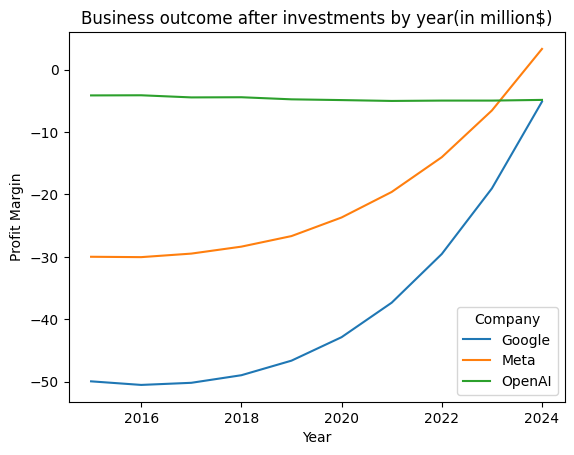

In [41]:
sns.lineplot(x='Year',y='Profits/Losses',data=yearly_data,hue='Company')
plt.title('Business outcome after investments by year(in million$)')
plt.ylabel('Profit Margin')
plt.xlabel('Year')
plt.show()